# AI-Based Intrusion Detection using the UNSW-NB15 Dataset

**Module:** MOD006570 - Cybersecurity and AI Case Studies

**Objective**

The objective of this project is to build and evaluate an Artificial Intelligence model capable of classifying network traffic as either normal or malicious using the UNSW-NB15 dataset.

**Import Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [2]:
train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df = pd.read_csv("UNSW_NB15_testing-set.csv")

In [3]:
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (175341, 45)
Testing Dataset Shape: (82332, 45)


In [4]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


**EDA**

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [6]:
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


**Missing Values**

In [7]:
train_df.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

In [8]:
train_df['label'].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

**Data Types**

In [13]:
train_df.dtypes

id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

**Visualisations**

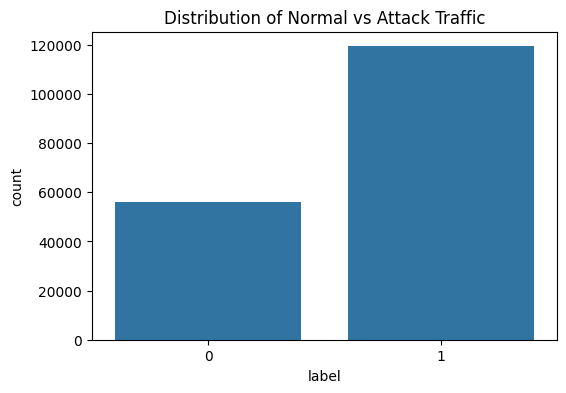

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=train_df)

plt.title("Distribution of Normal vs Attack Traffic")

plt.show()

In [10]:
train_df['proto'].value_counts().head(10)

proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
ipv6        201
mobile      201
Name: count, dtype: int64

In [11]:
train_df['service'].value_counts().head(10)

service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

In [12]:
train_df['state'].value_counts()

state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

**Create Copies of the Data**

In [14]:
train_processed = train_df.copy()
test_processed = test_df.copy()

In [15]:
train_processed.drop(columns=['id', 'attack_cat'], inplace=True)
test_processed.drop(columns=['id', 'attack_cat'], inplace=True)

In [16]:
X_train = train_processed.drop('label', axis=1)
y_train = train_processed['label']

X_test = test_processed.drop('label', axis=1)
y_test = test_processed['label']

In [17]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (175341, 42)
y_train: (175341,)
X_test: (82332, 42)
y_test: (82332,)


**Identify Categorical Columns**

In [18]:
categorical_columns = X_train.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['proto', 'service', 'state'], dtype='object')


**Encoding**

In [20]:
from sklearn.preprocessing import OrdinalEncoder

categorical_columns = ['proto', 'service', 'state']

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[categorical_columns] = encoder.fit_transform(
    X_train[categorical_columns]
)

X_test[categorical_columns] = encoder.transform(
    X_test[categorical_columns]
)

In [21]:
X_train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.121478,113.0,0.0,2.0,6,4,258,172,74.087490,252,...,1,1,1,1,0,0,0,1,1,0
1,0.649902,113.0,0.0,2.0,14,38,734,42014,78.473372,62,...,1,1,1,2,0,0,0,1,6,0
2,1.623129,113.0,0.0,2.0,8,16,364,13186,14.170161,62,...,2,1,1,3,0,0,0,2,6,0
3,1.681642,113.0,3.0,2.0,12,12,628,770,13.677108,62,...,2,1,1,3,1,1,0,2,1,0
4,0.449454,113.0,0.0,2.0,10,6,534,268,33.373826,254,...,2,2,1,40,0,0,0,2,39,0


In [23]:
X_train.shape


(175341, 42)

In [24]:
X_test.shape

(82332, 42)

**Lesson 5 — Build the Model**

# Random Forest (Experiments)

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [29]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred = rf_model.predict(X_test)

**Random Forest Evaluation**

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8649


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.71      0.83     37000
           1       0.81      0.99      0.89     45332

    accuracy                           0.86     82332
   macro avg       0.89      0.85      0.86     82332
weighted avg       0.89      0.86      0.86     82332



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[26435 10565]
 [  560 44772]]


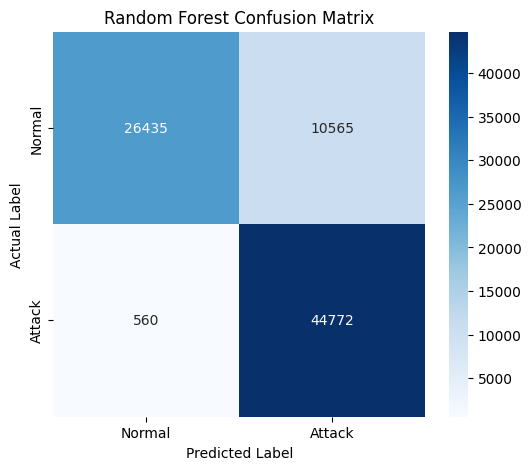

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

**Decision Tree Experiment**

# Decision Tree (Experiments)

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5
)

In [37]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
dt_pred = dt_model.predict(X_test)

**Decision Tree Evaluation**

In [39]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.8689


In [40]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84     37000
           1       0.85      0.93      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.87      0.86      0.87     82332
weighted avg       0.87      0.87      0.87     82332



In [41]:
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[29406  7594]
 [ 3199 42133]]


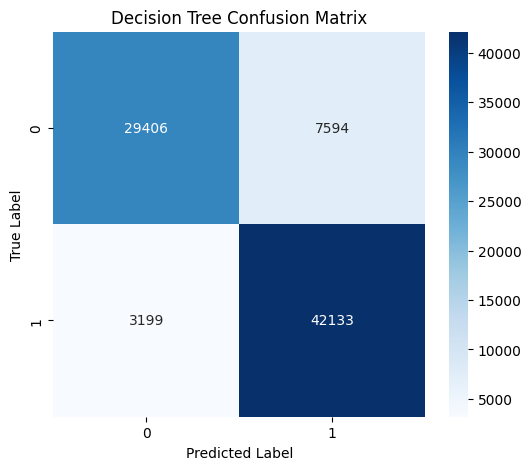

In [42]:
plt.figure(figsize=(6,5))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Model Comparison

In [43]:
# Random Forest 
rf_report = classification_report(y_test, y_pred, output_dict=True)

# Decision Tree 
dt_report = classification_report(y_test, dt_pred, output_dict=True)

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, y_pred)
    ],
    'Precision (Attack)': [
        dt_report['1']['precision'],
        rf_report['1']['precision']
    ],
    'Recall (Attack)': [
        dt_report['1']['recall'],
        rf_report['1']['recall']
    ],
    'F1-Score (Attack)': [
        dt_report['1']['f1-score'],
        rf_report['1']['f1-score']
    ]
})

comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision (Attack),Recall (Attack),F1-Score (Attack)
0,Decision Tree,0.8689,0.8473,0.9294,0.8865
1,Random Forest,0.8649,0.8091,0.9876,0.8895


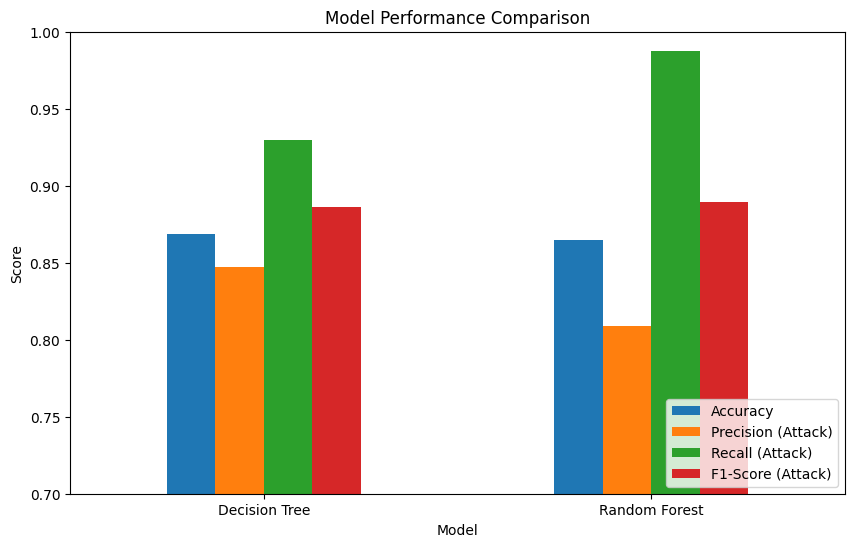

In [44]:
comparison_plot = comparison.set_index('Model')

comparison_plot.plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

**Feature Importance**

In [48]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        dt_accuracy,
        accuracy
    ],
    "Attack Precision": [
        0.85,
        0.81
    ],
    "Attack Recall": [
        0.93,
        0.99
    ],
    "Attack F1": [
        0.89,
        0.89
    ]
})

comparison

,Model,Accuracy,Attack Precision,Attack Recall,Attack F1
0,Decision Tree,0.868909,0.85,0.93,0.89
1,Random Forest,0.864876,0.81,0.99,0.89


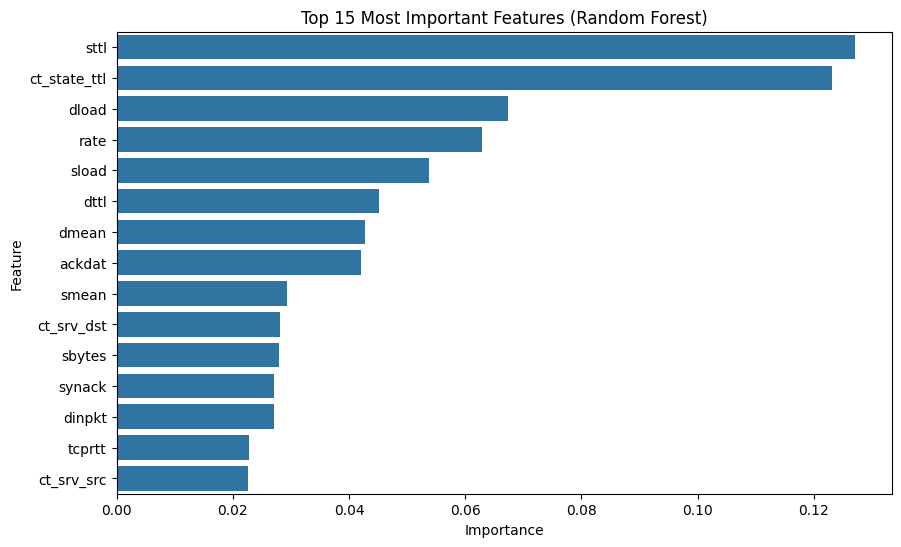

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Most Important Features (Random Forest)")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [46]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,sttl,0.127009
31,ct_state_ttl,0.123110
12,dload,0.067356
8,rate,0.062905
11,sload,0.053736
10,dttl,0.045158
27,dmean,0.042795
25,ackdat,0.042026
26,smean,0.029364
40,ct_srv_dst,0.028173


# Part B: Data Poisoning Attack on the Intrusion Detection Model

In this section, we investigate the impact of data poisoning attacks on the Random Forest intrusion detection model developed in Part A.

Two poisoning strategies will be evaluated:

- Random Label Flipping
- Targeted Attack Label Flipping

The performance of the model will be evaluated under different poisoning percentages and compared with the original clean model.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Random Label Flipping Function

The following function randomly selects a percentage of training labels and flips them. 

In [54]:
def random_label_flip(y, flip_percentage, random_state=42):
    """
    Randomly flips a percentage of labels.
    """

    np.random.seed(random_state)

    y_poisoned = y.copy()

    n_samples = len(y)

    n_flip = int(n_samples * flip_percentage)

    flip_indices = np.random.choice(
        n_samples,
        size=n_flip,
        replace=False
    )

    y_poisoned.iloc[flip_indices] = 1 - y_poisoned.iloc[flip_indices]

    return y_poisoned

In [55]:
poison_levels = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

In [56]:
random_results = []

## Random Label Poisoning Experiment

The model is retrained using increasingly poisoned datasets.

For each poisoning percentage, the following performance metrics are recorded:

- Accuracy
- Precision
- Recall
- F1-score
- False Negatives

In [57]:
for poison in poison_levels:

    # Poison labels
    poisoned_y = random_label_flip(y_train, poison)

    # Train model
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, poisoned_y)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    cm = confusion_matrix(y_test, predictions)

    false_negatives = cm[1][0]

    random_results.append([
        poison * 100,
        accuracy,
        precision,
        recall,
        f1,
        false_negatives
    ])

In [58]:
random_results_df = pd.DataFrame(
    random_results,
    columns=[
        "Poison (%)",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Negatives"
    ]
)

random_results_df

,Poison (%),Accuracy,Precision,Recall,F1 Score,False Negatives
0,5.0,0.863370,0.810020,0.982220,0.887848,806
1,10.0,0.852961,0.799495,0.978293,0.879903,984
2,15.0,0.847301,0.798437,0.966712,0.874553,1509
3,20.0,0.845674,0.805178,0.949440,0.871379,2292
4,25.0,0.827843,0.791501,0.933138,0.856504,3031
5,30.0,0.812697,0.788110,0.902453,0.841415,4422


## Impact of Random Label Flipping on Model Accuracy

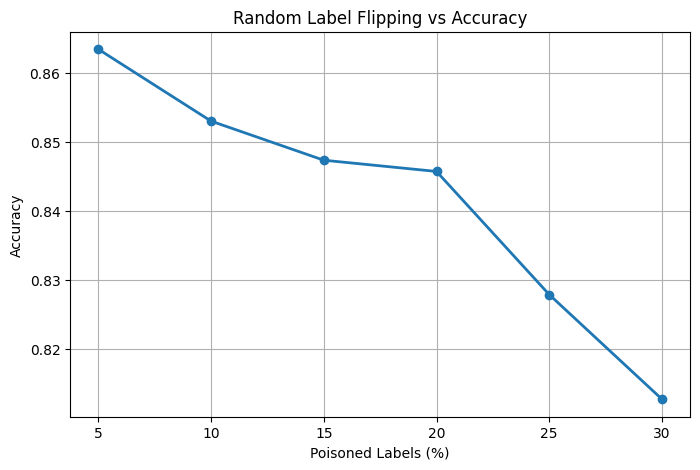

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    random_results_df["Poison (%)"],
    random_results_df["Accuracy"],
    marker='o',
    linewidth=2
)

plt.title("Random Label Flipping vs Accuracy")

plt.xlabel("Poisoned Labels (%)")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

## Impact of Random Label Flipping on Attack Recall

Recall is the most important metric for intrusion detection because it measures the model's ability to correctly identify malicious traffic.

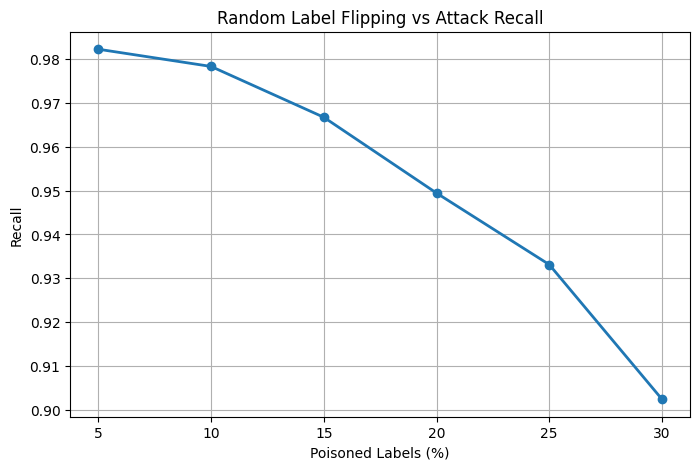

In [60]:
plt.figure(figsize=(8,5))

plt.plot(
    random_results_df["Poison (%)"],
    random_results_df["Recall"],
    marker='o',
    linewidth=2
)

plt.title("Random Label Flipping vs Attack Recall")

plt.xlabel("Poisoned Labels (%)")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

## Impact of Random Label Flipping on False Negatives

False negatives represent malicious attacks that were incorrectly classified as normal traffic. 

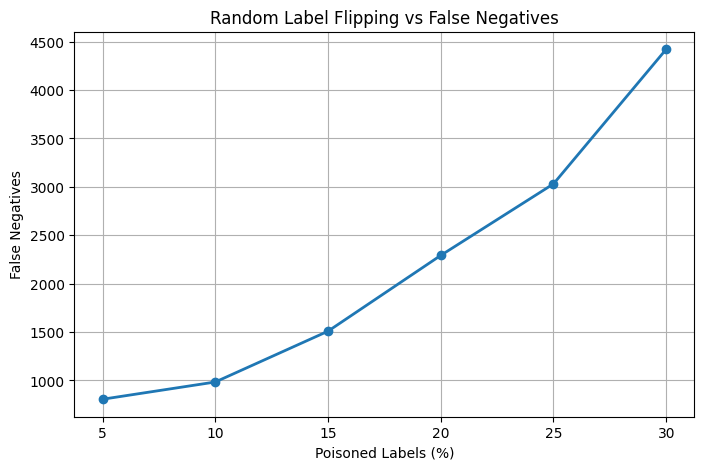

In [61]:
plt.figure(figsize=(8,5))

plt.plot(
    random_results_df["Poison (%)"],
    random_results_df["False Negatives"],
    marker='o',
    linewidth=2
)

plt.title("Random Label Flipping vs False Negatives")

plt.xlabel("Poisoned Labels (%)")

plt.ylabel("False Negatives")

plt.grid(True)

plt.show()

# Targeted Attack Label Flipping

Unlike random label flipping, this strategy only manipulates malicious samples.

The attacker changes a percentage of attack labels (1) into benign labels (0), while leaving normal traffic unchanged.


In [62]:
def targeted_label_flip(y, flip_percentage, random_state=42):
    """
    Flip only attack labels (1 -> 0)
    """

    np.random.seed(random_state)

    y_poisoned = y.copy()

    attack_indices = y_poisoned[y_poisoned == 1].index

    n_flip = int(len(attack_indices) * flip_percentage)

    flip_indices = np.random.choice(
        attack_indices,
        size=n_flip,
        replace=False
    )

    y_poisoned.loc[flip_indices] = 0

    return y_poisoned

In [63]:
targeted_results = []

## Targeted Label Poisoning Experiment

The Random Forest classifier is retrained after systematically converting a percentage of attack labels into benign labels.

Performance is evaluated using the same metrics as the random poisoning experiment to enable a fair comparison.

In [65]:
for poison in poison_levels:

    poisoned_y = targeted_label_flip(y_train, poison)

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, poisoned_y)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    cm = confusion_matrix(y_test, predictions)

    false_negatives = cm[1][0]

    targeted_results.append([
        poison * 100,
        accuracy,
        precision,
        recall,
        f1,
        false_negatives
    ])

In [66]:
targeted_results_df = pd.DataFrame(
    targeted_results,
    columns=[
        "Poison (%)",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Negatives"
    ]
)

targeted_results_df

,Poison (%),Accuracy,Precision,Recall,F1 Score,False Negatives
0,5.0,0.873634,0.825736,0.976595,0.894852,1061
1,10.0,0.881626,0.843946,0.963095,0.899592,1673
2,15.0,0.883083,0.854142,0.949859,0.899461,2273
3,20.0,0.881176,0.870851,0.920740,0.895101,3593
4,25.0,0.878638,0.894121,0.884298,0.889182,5245
5,30.0,0.876051,0.902307,0.868967,0.885323,5940


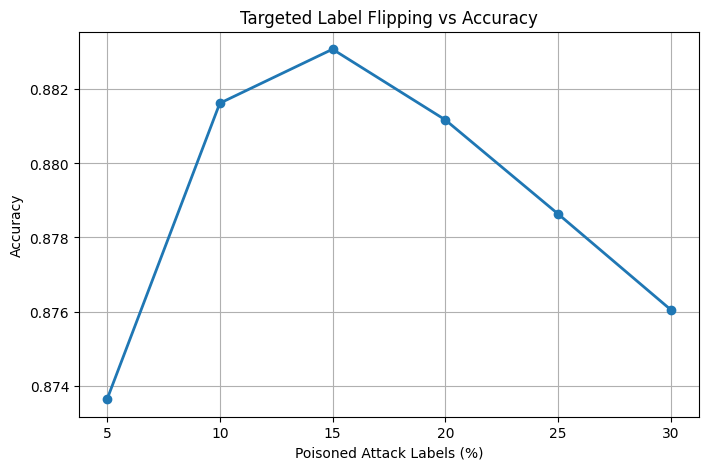

In [67]:
plt.figure(figsize=(8,5))

plt.plot(
    targeted_results_df["Poison (%)"],
    targeted_results_df["Accuracy"],
    marker='o',
    linewidth=2
)

plt.title("Targeted Label Flipping vs Accuracy")

plt.xlabel("Poisoned Attack Labels (%)")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

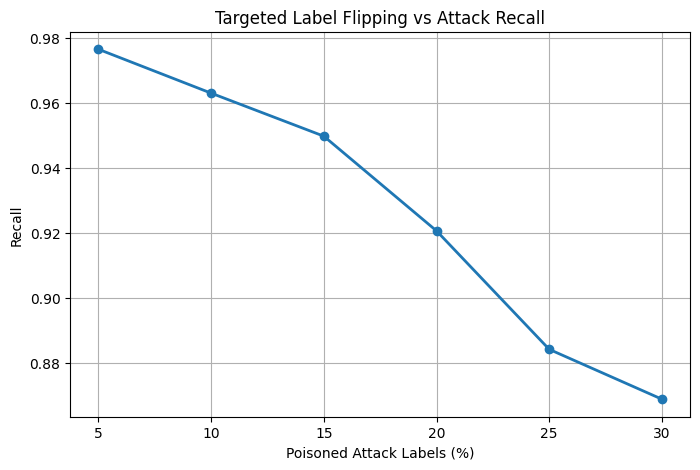

In [68]:
plt.figure(figsize=(8,5))

plt.plot(
    targeted_results_df["Poison (%)"],
    targeted_results_df["Recall"],
    marker='o',
    linewidth=2
)

plt.title("Targeted Label Flipping vs Attack Recall")

plt.xlabel("Poisoned Attack Labels (%)")

plt.ylabel("Recall")

plt.grid(True)

plt.show()

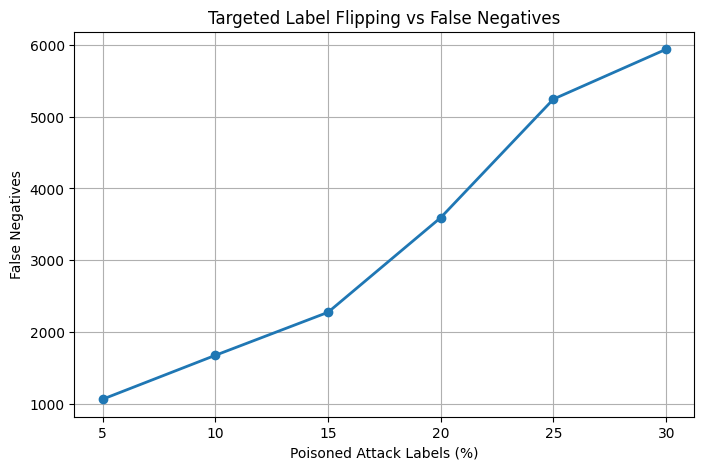

In [69]:
plt.figure(figsize=(8,5))

plt.plot(
    targeted_results_df["Poison (%)"],
    targeted_results_df["False Negatives"],
    marker='o',
    linewidth=2
)

plt.title("Targeted Label Flipping vs False Negatives")

plt.xlabel("Poisoned Attack Labels (%)")

plt.ylabel("False Negatives")

plt.grid(True)

plt.show()

# Comparison of Poisoning Strategies

The following table compares the impact of random label flipping and targeted attack label flipping on the performance of the Random Forest intrusion detection model.

In [70]:
comparison_df = pd.DataFrame({
    "Poison (%)": poison_levels,
    "Random Accuracy": random_results_df["Accuracy"],
    "Targeted Accuracy": targeted_results_df["Accuracy"],
    "Random Recall": random_results_df["Recall"],
    "Targeted Recall": targeted_results_df["Recall"],
    "Random False Negatives": random_results_df["False Negatives"],
    "Targeted False Negatives": targeted_results_df["False Negatives"]
})

comparison_df["Poison (%)"] = comparison_df["Poison (%)"] * 100

comparison_df

,Poison (%),Random Accuracy,Targeted Accuracy,Random Recall,Targeted Recall,Random False Negatives,Targeted False Negatives
0,5.0,0.863370,0.873634,0.982220,0.976595,806,1061
1,10.0,0.852961,0.881626,0.978293,0.963095,984,1673
2,15.0,0.847301,0.883083,0.966712,0.949859,1509,2273
3,20.0,0.845674,0.881176,0.949440,0.920740,2292,3593
4,25.0,0.827843,0.878638,0.933138,0.884298,3031,5245
5,30.0,0.812697,0.876051,0.902453,0.868967,4422,5940


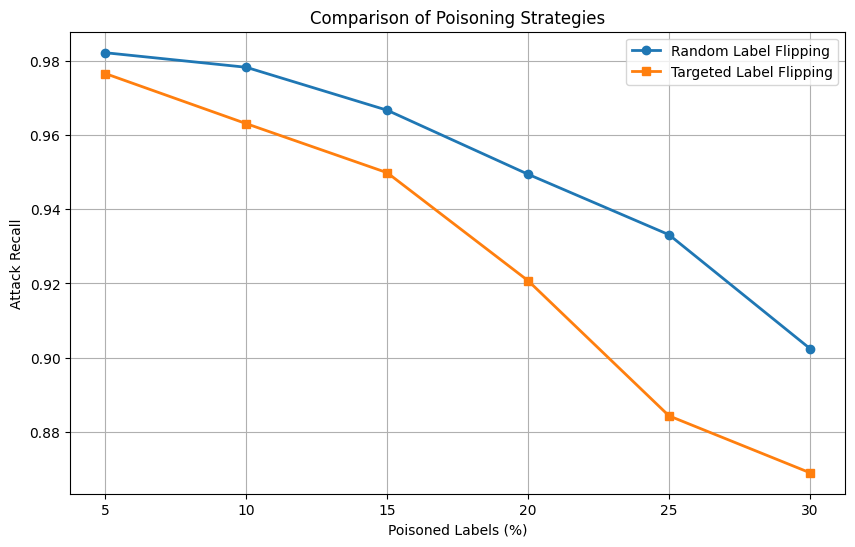

In [71]:
plt.figure(figsize=(10,6))

plt.plot(
    comparison_df["Poison (%)"],
    comparison_df["Random Recall"],
    marker='o',
    linewidth=2,
    label="Random Label Flipping"
)

plt.plot(
    comparison_df["Poison (%)"],
    comparison_df["Targeted Recall"],
    marker='s',
    linewidth=2,
    label="Targeted Label Flipping"
)

plt.title("Comparison of Poisoning Strategies")

plt.xlabel("Poisoned Labels (%)")

plt.ylabel("Attack Recall")

plt.legend()

plt.grid(True)

plt.show()

## Comparison of False Negatives

False negatives represent malicious network attacks that were incorrectly classified as normal traffic.

In intrusion detection systems, false negatives are considered the most critical type of error because they allow cyber attacksZ

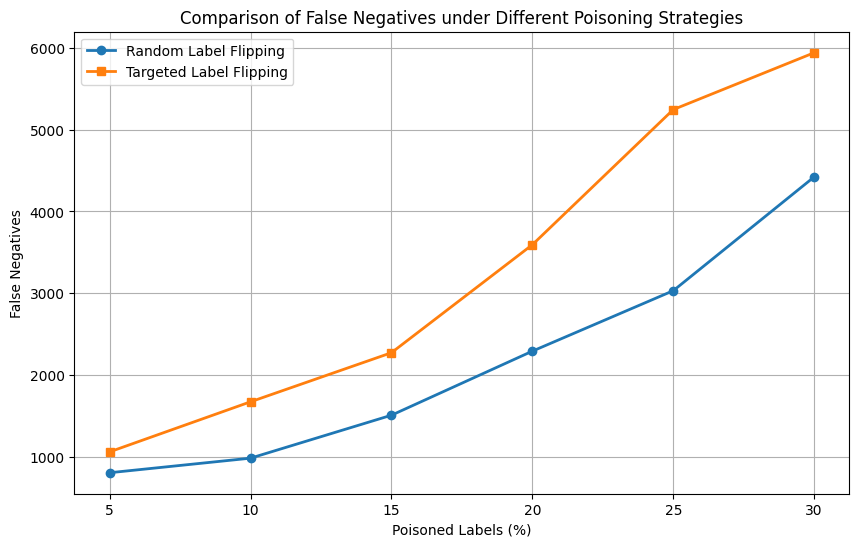

In [72]:
plt.figure(figsize=(10,6))

plt.plot(
    comparison_df["Poison (%)"],
    comparison_df["Random False Negatives"],
    marker='o',
    linewidth=2,
    label="Random Label Flipping"
)

plt.plot(
    comparison_df["Poison (%)"],
    comparison_df["Targeted False Negatives"],
    marker='s',
    linewidth=2,
    label="Targeted Label Flipping"
)

plt.title("Comparison of False Negatives under Different Poisoning Strategies")

plt.xlabel("Poisoned Labels (%)")

plt.ylabel("False Negatives")

plt.legend()

plt.grid(True)

plt.show()